# Project 3 - Transforming Fashion

This notebook implements the parts requested for:

- **Opdracht 1: Exploratieve Data Analyse**
- **Opdracht 2: Objectdetectie**

The goal is to make the dataset understandable before training, then build a YOLO object detector
for the ten clothing and accessory classes from the assignment.


## 0. Setup and Path Safety

All generated files, caches, split files, figures, model runs, and submission files are kept inside
this `project_3` folder. This matters because the repo is the working drive and local downloads/home
caches should not be used.


In [12]:
from pathlib import Path
import ast
import json
import os
import random
import re
import time
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from typing import Iterable

NOTEBOOK_NAME = "DL_CV_Project3_Transforming_Fashion_EDA_Objectdetectie.ipynb"
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / NOTEBOOK_NAME).exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR / "project_3" / NOTEBOOK_NAME).exists():
    PROJECT_DIR = (CURRENT_DIR / "project_3").resolve()
else:
    raise RuntimeError("Open this notebook from the repo root or from the project_3 folder.")

DATASET_DIR = PROJECT_DIR / "Dataset"
TRAIN_IMAGES_DIR = DATASET_DIR / "Train" / "images"
TRAIN_LABELS_DIR = DATASET_DIR / "Train" / "labels"
TEST_IMAGES_DIR = DATASET_DIR / "Test" / "images"
SUBMISSION_EXAMPLE_PATH = DATASET_DIR / "submission_example.csv"

CACHE_DIR = PROJECT_DIR / ".cache"
EDA_CACHE_DIR = CACHE_DIR / "eda"
RUNS_DIR = PROJECT_DIR / "runs"
SPLITS_DIR = PROJECT_DIR / "splits"
FIGURES_DIR = PROJECT_DIR / "figures"
for folder in [CACHE_DIR, EDA_CACHE_DIR, RUNS_DIR, SPLITS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# iCloud can keep repo files as placeholders. Reading thousands of placeholders can
# make EDA look frozen, so the default run uses a bounded, deterministic sample.
# Set FULL_EDA = True for the final report after the Dataset folder is fully materialized.
FULL_EDA = False
EDA_LABEL_SAMPLE_SIZE = 120
EDA_LABEL_WORKERS = 8
EDA_IMAGE_SIZE_SAMPLE = 8

os.environ["HF_HOME"] = str(CACHE_DIR / "huggingface")
os.environ["HF_DATASETS_CACHE"] = str(CACHE_DIR / "huggingface" / "datasets")
os.environ["TRANSFORMERS_CACHE"] = str(CACHE_DIR / "huggingface" / "transformers")
os.environ["TORCH_HOME"] = str(CACHE_DIR / "torch")
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")
os.environ["YOLO_CONFIG_DIR"] = str(CACHE_DIR / "ultralytics")
os.environ["ULTRALYTICS_SETTINGS"] = str(CACHE_DIR / "ultralytics" / "settings.json")

ALLOWED_ROOT = PROJECT_DIR.resolve()

def assert_inside_project(path: Path) -> Path:
    resolved = path.resolve()
    if resolved != ALLOWED_ROOT and ALLOWED_ROOT not in resolved.parents:
        raise RuntimeError(f"Path escapes project_3: {resolved}")
    return resolved

for configured_path in [CACHE_DIR, EDA_CACHE_DIR, RUNS_DIR, SPLITS_DIR, FIGURES_DIR]:
    assert_inside_project(configured_path)

print(f"Project folder: {PROJECT_DIR}")
print(f"Cache folder: {CACHE_DIR}")


Project folder: /Users/duanewiegel/Documents/GitHub/DL-CV/project_3
Cache folder: /Users/duanewiegel/Documents/GitHub/DL-CV/project_3/.cache


In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

try:
    import torch
except ImportError:
    torch = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",
}
CLASS_NAME_SET = set(CLASS_NAMES.values())

CHART_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "pink": "#B279A2",
    "gold": "#ECA82C",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.grid": True,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [14]:
def choose_device() -> str:
    if torch is None:
        return "cpu"
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = choose_device()
print(f"Selected training device: {DEVICE}")


Selected training device: mps


## 1. Team and Kaggle Information

Fill this in before exporting the notebook to HTML.


| Field | Value |
|---|---|
| Team name | TODO |
| Kaggle competition | Transforming Fashion 2026 |
| Team member 1 | TODO - name and Kaggle username |
| Team member 2 | TODO - name and Kaggle username |
| Team member 3 | TODO - name and Kaggle username |
| Team member 4 | TODO - name and Kaggle username |


## 2. Opdracht 1: Exploratieve Data Analyse

**Chart contract.** The EDA uses comparison, distribution, ranking, matrix, and spatial-density
visuals because the core questions are: what classes exist, how imbalanced are they, where do
boxes appear, how large are objects, and which classes appear together?

**Cloud-safe default.** This repo lives in iCloud Drive. If files are placeholders, opening every
label/image can be slower than the actual analysis. The notebook therefore runs with `FULL_EDA = False`
by default, using a deterministic sample that prefers already-materialized files. For the final exported
report, set `FULL_EDA = True` after iCloud has finished downloading the `Dataset` folder.


In [15]:
def list_images(folder: Path) -> list[Path]:
    return sorted(
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


train_images = list_images(TRAIN_IMAGES_DIR)
test_images = list_images(TEST_IMAGES_DIR)
train_labels = sorted(TRAIN_LABELS_DIR.glob("*.txt"))

train_image_stems = {path.stem for path in train_images}
train_label_stems = {path.stem for path in train_labels}

dataset_audit = {
    "train_images": len(train_images),
    "train_labels": len(train_labels),
    "test_images": len(test_images),
    "missing_label_files": len(train_image_stems - train_label_stems),
    "labels_without_images": len(train_label_stems - train_image_stems),
    "submission_example_exists": SUBMISSION_EXAMPLE_PATH.exists(),
}
pd.DataFrame([dataset_audit])


,train_images,train_labels,test_images,missing_label_files,labels_without_images,submission_example_exists
0,2145,2145,537,0,0,True


In [16]:
@dataclass(frozen=True)
class YoloBox:
    image_id: str
    class_id: int
    center_x: float
    center_y: float
    width: float
    height: float

    @property
    def class_name(self) -> str:
        return CLASS_NAMES[self.class_id]

    @property
    def area(self) -> float:
        return self.width * self.height

    @property
    def aspect_ratio(self) -> float:
        return self.width / self.height if self.height else np.nan


def is_probably_hydrated(path: Path) -> bool:
    """Return True when macOS reports local blocks for a cloud-backed file."""
    try:
        return getattr(path.stat(), "st_blocks", 1) > 0
    except OSError:
        return False


def select_label_paths_for_eda(label_paths: Iterable[Path]) -> tuple[list[Path], dict]:
    label_paths = list(label_paths)
    if FULL_EDA:
        return label_paths, {
            "mode": "full",
            "selected_label_files": len(label_paths),
            "total_label_files": len(label_paths),
            "hydrated_selected_files": sum(is_probably_hydrated(path) for path in label_paths),
        }

    hydrated = [path for path in label_paths if is_probably_hydrated(path)]
    hydrated_names = {path.name for path in hydrated}
    deferred = [path for path in label_paths if path.name not in hydrated_names]

    rng = random.Random(SEED)
    rng.shuffle(hydrated)
    rng.shuffle(deferred)
    selected = (hydrated + deferred)[:min(EDA_LABEL_SAMPLE_SIZE, len(label_paths))]
    selected = sorted(selected, key=lambda path: path.name)
    return selected, {
        "mode": "sampled_cloud_safe",
        "selected_label_files": len(selected),
        "total_label_files": len(label_paths),
        "hydrated_selected_files": sum(is_probably_hydrated(path) for path in selected),
        "hydrated_available_files": len(hydrated),
    }


def parse_label_file(label_path: Path) -> list[YoloBox]:
    boxes = []
    for line_number, line in enumerate(label_path.read_text().splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"{label_path.name}:{line_number} has {len(parts)} values")
        class_id, center_x, center_y, width, height = parts
        class_id = int(float(class_id))
        if class_id not in CLASS_NAMES:
            raise ValueError(f"Unknown class id {class_id} in {label_path.name}")
        boxes.append(
            YoloBox(
                image_id=label_path.stem,
                class_id=class_id,
                center_x=float(center_x),
                center_y=float(center_y),
                width=float(width),
                height=float(height),
            )
        )
    return boxes


def label_file_to_rows(label_path: Path) -> list[dict]:
    return [
        {
            "image_id": box.image_id,
            "class_id": box.class_id,
            "class_name": box.class_name,
            "center_x": box.center_x,
            "center_y": box.center_y,
            "width": box.width,
            "height": box.height,
            "area": box.area,
            "aspect_ratio": box.aspect_ratio,
        }
        for box in parse_label_file(label_path)
    ]


def parse_labels_cached(label_paths: Iterable[Path], cache_name: str, max_workers: int) -> pd.DataFrame:
    cache_path = EDA_CACHE_DIR / cache_name
    assert_inside_project(cache_path)
    if cache_path.exists():
        print(f"Loading cached label manifest: {cache_path}")
        return pd.read_csv(cache_path)

    label_paths = list(label_paths)
    started = time.perf_counter()
    rows = []
    completed = 0
    print(f"Building label manifest from {len(label_paths)} files with {max_workers} workers...")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(label_file_to_rows, label_path) for label_path in label_paths]
        for future in as_completed(futures):
            rows.extend(future.result())
            completed += 1
            if completed % 25 == 0 or completed == len(label_paths):
                elapsed = time.perf_counter() - started
                print(f"Parsed {completed}/{len(label_paths)} label files in {elapsed:.1f}s")

    labels = pd.DataFrame(rows)
    labels.to_csv(cache_path, index=False)
    print(f"Saved label manifest: {cache_path}")
    return labels


eda_label_paths, eda_label_scope = select_label_paths_for_eda(train_labels)
cache_suffix = "full" if FULL_EDA else f"sample_{len(eda_label_paths)}"
labels_df = parse_labels_cached(
    eda_label_paths,
    cache_name=f"labels_manifest_{cache_suffix}.csv",
    max_workers=EDA_LABEL_WORKERS,
)
print(eda_label_scope)
labels_df.head()


Loading cached label manifest: /Users/duanewiegel/Documents/GitHub/DL-CV/project_3/.cache/eda/labels_manifest_sample_120.csv
{'mode': 'sampled_cloud_safe', 'selected_label_files': 120, 'total_label_files': 2145, 'hydrated_selected_files': 0, 'hydrated_available_files': 0}


,image_id,class_id,class_name,center_x,center_y,width,height,area,aspect_ratio
0,185592,8,bag,0.57625,0.482500,0.1075,0.111667,0.012004,0.962684
1,185592,2,jacket,0.65125,0.520833,0.0625,0.041667,0.002604,1.499988
2,185592,2,jacket,0.53500,0.385000,0.4250,0.330000,0.140250,1.287879
3,185592,7,dress,0.52250,0.417500,0.3150,0.351667,0.110775,0.895734
4,185592,9,shoe,0.50750,0.845000,0.1200,0.130000,0.015600,0.923077


In [17]:
coordinate_columns = ["center_x", "center_y", "width", "height"]
coordinate_valid = labels_df[coordinate_columns].apply(lambda column: column.between(0, 1)).all(axis=1)
boxes_per_image = labels_df.groupby("image_id").size().rename("box_count")

eda_scorecard = pd.DataFrame([
    {"metric": "Training images", "value": len(train_images)},
    {"metric": "Test images", "value": len(test_images)},
    {"metric": "Bounding boxes", "value": len(labels_df)},
    {"metric": "Classes", "value": labels_df["class_id"].nunique()},
    {"metric": "Images with 3+ objects", "value": int((boxes_per_image >= 3).sum())},
    {"metric": "Invalid coordinate rows", "value": int((~coordinate_valid).sum())},
])
eda_scorecard


,metric,value
0,Training images,2145
1,Test images,537
2,Bounding boxes,471
3,Classes,10
4,Images with 3+ objects,115
5,Invalid coordinate rows,0


In [18]:
class_summary = (
    labels_df.groupby(["class_id", "class_name"])
    .agg(
        box_count=("image_id", "size"),
        image_count=("image_id", "nunique"),
        median_area=("area", "median"),
        mean_area=("area", "mean"),
        median_aspect_ratio=("aspect_ratio", "median"),
    )
    .reset_index()
)
class_summary["box_share"] = class_summary["box_count"] / class_summary["box_count"].sum()
class_summary["rank"] = class_summary["box_count"].rank(method="first", ascending=False).astype(int)
class_summary.sort_values("box_count", ascending=False)


,class_id,class_name,box_count,image_count,median_area,mean_area,median_aspect_ratio,box_share,rank
9,9,shoe,114,114,0.019190,0.023748,1.546413,0.242038,1
3,3,shirt,90,90,0.062183,0.067229,1.201564,0.191083,2
8,8,bag,64,64,0.035238,0.042011,0.969295,0.135881,3
6,6,skirt,44,44,0.080598,0.099283,1.295812,0.093418,4
2,2,jacket,40,39,0.136750,0.136659,1.195731,0.084926,5
4,4,pants,27,27,0.109975,0.107176,0.676056,0.057325,6
5,5,shorts,26,26,0.037869,0.041141,2.109516,0.055202,7
0,0,sunglass,22,22,0.004815,0.005494,2.114634,0.046709,8
1,1,hat,22,22,0.014892,0.016203,2.062548,0.046709,9
7,7,dress,22,22,0.139350,0.155009,0.882161,0.046709,10


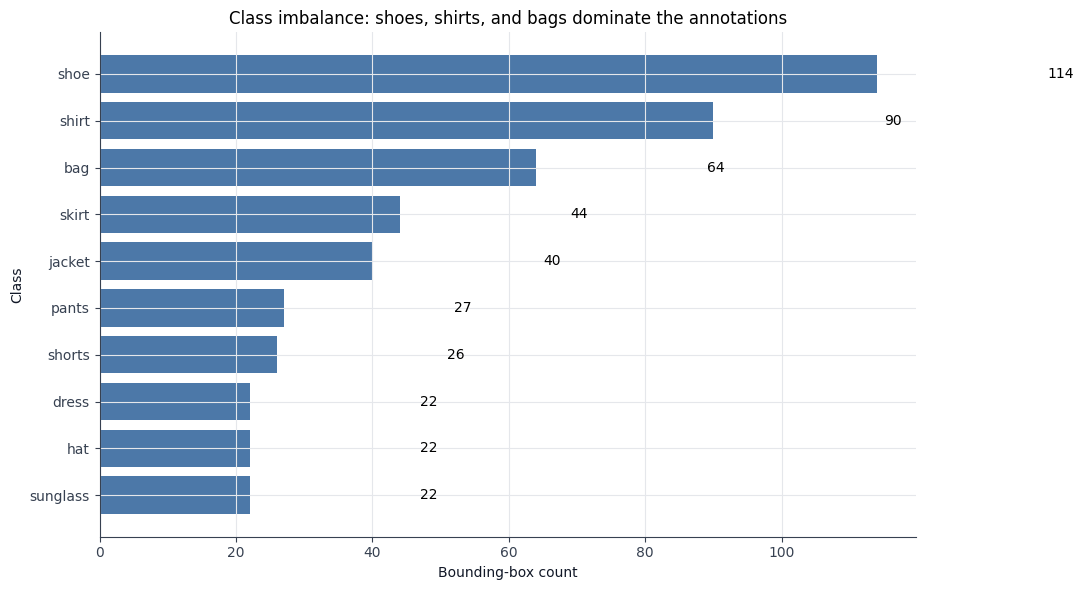

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
ordered = class_summary.sort_values("box_count")
ax.barh(ordered["class_name"], ordered["box_count"], color=CHART_COLORS["blue"])
for y_index, value in enumerate(ordered["box_count"]):
    ax.text(value + 25, y_index, f"{value:,}", va="center", fontsize=10)
ax.set_title("Class imbalance: shoes, shirts, and bags dominate the annotations")
ax.set_xlabel("Bounding-box count")
ax.set_ylabel("Class")
plt.tight_layout()


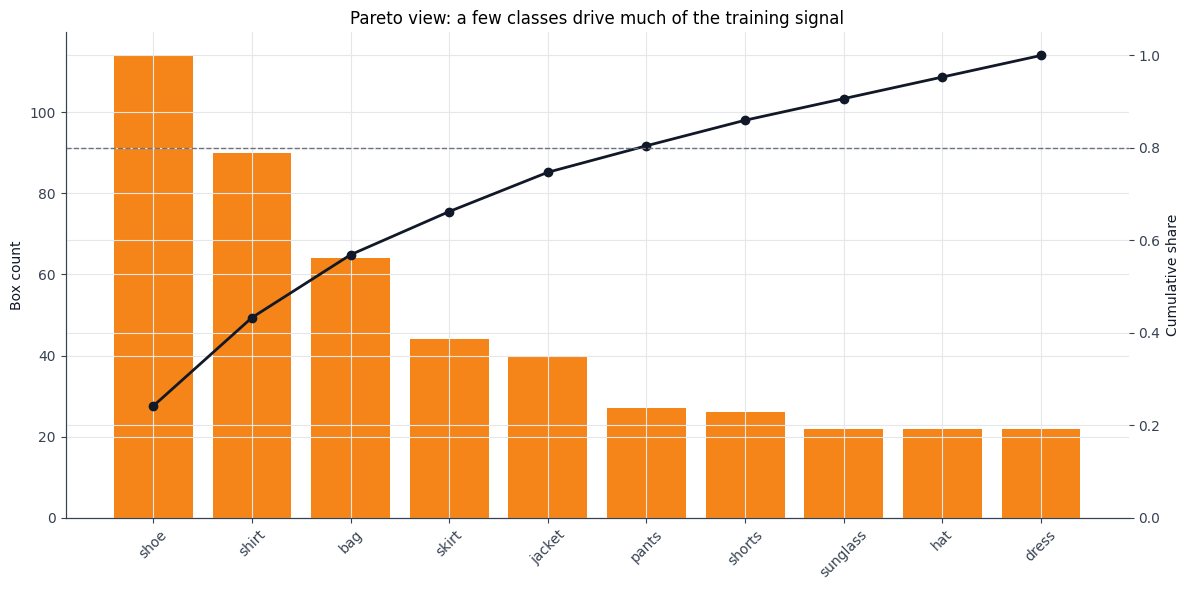

In [20]:
pareto = class_summary.sort_values("box_count", ascending=False).copy()
pareto["cumulative_share"] = pareto["box_count"].cumsum() / pareto["box_count"].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(pareto["class_name"], pareto["box_count"], color=CHART_COLORS["orange"])
ax1.set_ylabel("Box count")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Pareto view: a few classes drive much of the training signal")

ax2 = ax1.twinx()
ax2.plot(pareto["class_name"], pareto["cumulative_share"], color="#111827", marker="o", linewidth=2)
ax2.axhline(0.8, color=CHART_COLORS["gray"], linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative share")
ax2.set_ylim(0, 1.05)
plt.tight_layout()


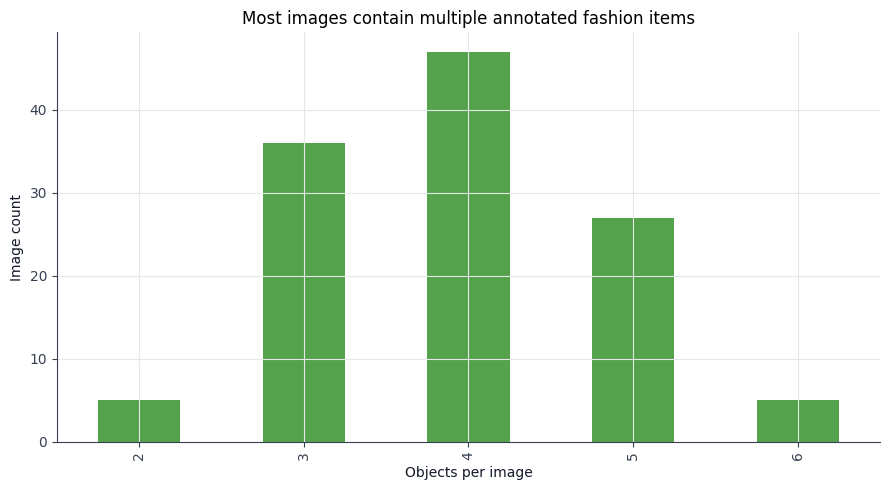

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
boxes_per_image.value_counts().sort_index().plot(
    kind="bar",
    ax=ax,
    color=CHART_COLORS["green"],
)
ax.set_title("Most images contain multiple annotated fashion items")
ax.set_xlabel("Objects per image")
ax.set_ylabel("Image count")
plt.tight_layout()


In [22]:
IMAGE_SIZE_COLUMNS = ["split", "image_id", "file_name", "width_px", "height_px", "image_aspect_ratio"]


def choose_image_paths_for_eda(image_paths: Iterable[Path], sample_size: int) -> list[Path]:
    paths = list(image_paths)
    if FULL_EDA:
        selected = paths
    else:
        hydrated = [path for path in paths if is_probably_hydrated(path)]
        source = hydrated if hydrated else []
        selected = source[:]
        random.Random(SEED).shuffle(selected)
        selected = selected[:sample_size]
    return sorted(selected, key=lambda path: path.name)


def image_size_table(image_paths: Iterable[Path], split: str, sample_size: int) -> pd.DataFrame:
    paths = choose_image_paths_for_eda(image_paths, sample_size=sample_size)
    rows = []
    if not paths:
        print(f"No hydrated {split} images available for fast image-size EDA; skipping image opens.")
        return pd.DataFrame(columns=IMAGE_SIZE_COLUMNS)

    for image_path in paths:
        with Image.open(image_path) as image:
            rows.append({
                "split": split,
                "image_id": image_path.stem,
                "file_name": image_path.name,
                "width_px": image.width,
                "height_px": image.height,
                "image_aspect_ratio": image.width / image.height,
            })
    return pd.DataFrame(rows, columns=IMAGE_SIZE_COLUMNS)


def load_or_build_image_size_sample() -> pd.DataFrame:
    cache_name = "image_size_full.csv" if FULL_EDA else f"image_size_hydrated_sample_{EDA_IMAGE_SIZE_SAMPLE}.csv"
    cache_path = EDA_CACHE_DIR / cache_name
    assert_inside_project(cache_path)
    if cache_path.exists():
        print(f"Loading cached image-size sample: {cache_path}")
        return pd.read_csv(cache_path)

    started = time.perf_counter()
    image_sizes = pd.concat(
        [
            image_size_table(train_images, "train", sample_size=EDA_IMAGE_SIZE_SAMPLE),
            image_size_table(test_images, "test", sample_size=EDA_IMAGE_SIZE_SAMPLE),
        ],
        ignore_index=True,
    )
    image_sizes.to_csv(cache_path, index=False)
    print(f"Saved image-size sample in {time.perf_counter() - started:.1f}s: {cache_path}")
    return image_sizes


image_sizes_df = load_or_build_image_size_sample()

if image_sizes_df.empty:
    pd.DataFrame([{"message": "Image-size EDA skipped because no train/test images are hydrated locally."}])
else:
    image_sizes_df.groupby("split").agg(
        sampled_images=("image_id", "count"),
        min_width=("width_px", "min"),
        median_width=("width_px", "median"),
        max_width=("width_px", "max"),
        min_height=("height_px", "min"),
        median_height=("height_px", "median"),
        max_height=("height_px", "max"),
    )


Saved image-size sample in 0.1s: /Users/duanewiegel/Documents/GitHub/DL-CV/project_3/.cache/eda/image_size_hydrated_sample_8.csv


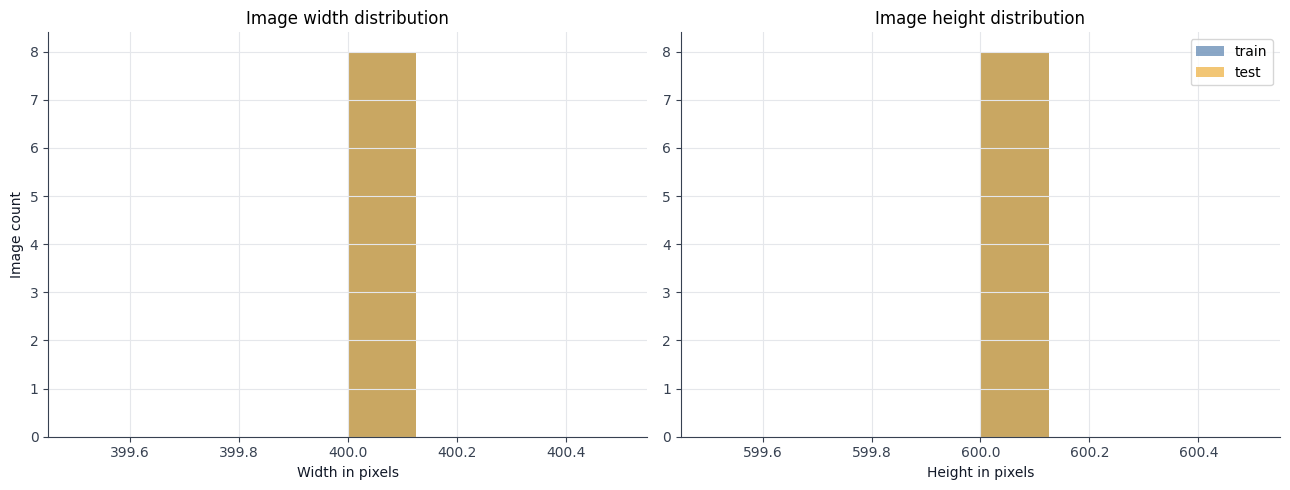

In [23]:
if image_sizes_df.empty:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.text(
        0.5,
        0.5,
        "Image-size histogram skipped: no hydrated images available in the iCloud-backed repo.",
        ha="center",
        va="center",
        wrap=True,
    )
    ax.axis("off")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for split, color in [("train", CHART_COLORS["blue"]), ("test", CHART_COLORS["gold"])]:
        subset = image_sizes_df[image_sizes_df["split"] == split]
        if subset.empty:
            continue
        axes[0].hist(subset["width_px"], bins=min(10, max(1, len(subset))), alpha=0.65, label=split, color=color)
        axes[1].hist(subset["height_px"], bins=min(10, max(1, len(subset))), alpha=0.65, label=split, color=color)

    axes[0].set_title("Image width distribution")
    axes[0].set_xlabel("Width in pixels")
    axes[0].set_ylabel("Image count")
    axes[1].set_title("Image height distribution")
    axes[1].set_xlabel("Height in pixels")
    axes[1].legend()
    plt.tight_layout()


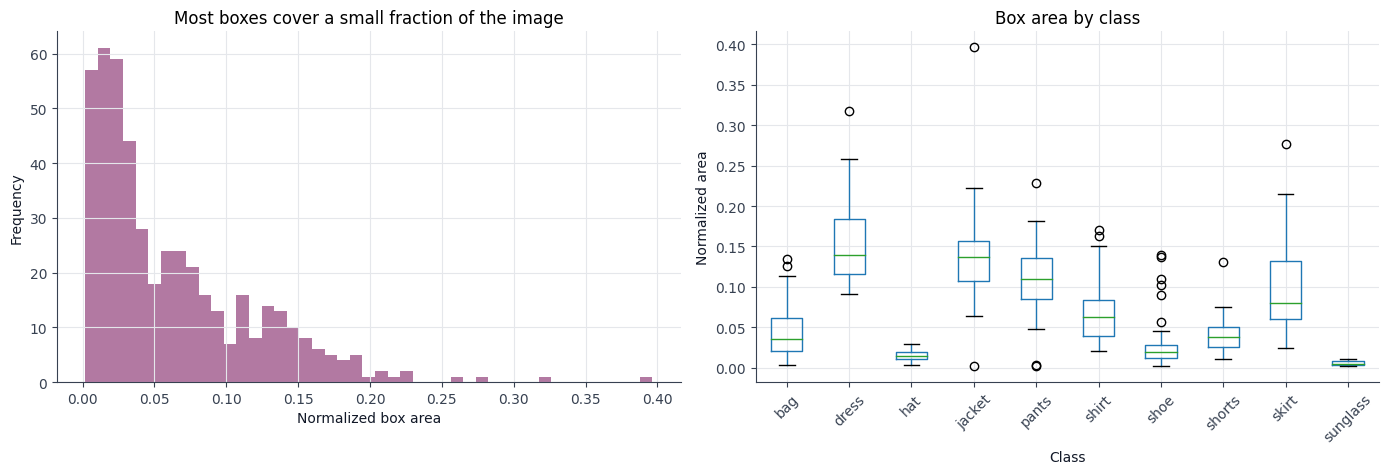

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_df["area"].plot(
    kind="hist",
    bins=45,
    ax=axes[0],
    color=CHART_COLORS["pink"],
)
axes[0].set_title("Most boxes cover a small fraction of the image")
axes[0].set_xlabel("Normalized box area")

labels_df.boxplot(column="area", by="class_name", ax=axes[1], rot=45)
axes[1].set_title("Box area by class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Normalized area")
fig.suptitle("")
plt.tight_layout()


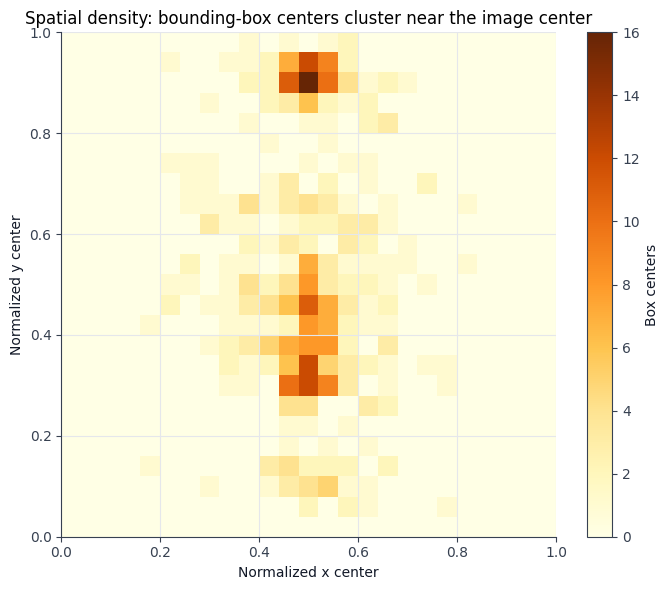

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
heatmap, x_edges, y_edges = np.histogram2d(
    labels_df["center_x"],
    labels_df["center_y"],
    bins=25,
    range=[[0, 1], [0, 1]],
)
image = ax.imshow(
    heatmap.T,
    origin="lower",
    cmap="YlOrBr",
    extent=[0, 1, 0, 1],
    aspect="auto",
)
fig.colorbar(image, ax=ax, label="Box centers")
ax.set_title("Spatial density: bounding-box centers cluster near the image center")
ax.set_xlabel("Normalized x center")
ax.set_ylabel("Normalized y center")
plt.tight_layout()


In [26]:
image_class_matrix = (
    labels_df.assign(value=1)
    .pivot_table(index="image_id", columns="class_name", values="value", aggfunc="max", fill_value=0)
)
co_occurrence = image_class_matrix.T.dot(image_class_matrix)
np.fill_diagonal(co_occurrence.values, 0)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(co_occurrence, cmap="Blues")
ax.set_xticks(range(len(co_occurrence.columns)))
ax.set_xticklabels(co_occurrence.columns, rotation=45, ha="right")
ax.set_yticks(range(len(co_occurrence.index)))
ax.set_yticklabels(co_occurrence.index)
ax.set_title("Class co-occurrence: which items appear together?")
fig.colorbar(image, ax=ax, label="Images with both classes")
plt.tight_layout()


ValueError: underlying array is read-only

In [ ]:
def yolo_to_pixels(box_row: pd.Series, image_width: int, image_height: int) -> tuple[int, int, int, int]:
    box_width = box_row["width"] * image_width
    box_height = box_row["height"] * image_height
    x_min = (box_row["center_x"] * image_width) - (box_width / 2)
    y_min = (box_row["center_y"] * image_height) - (box_height / 2)
    return int(x_min), int(y_min), int(box_width), int(box_height)


def draw_boxes(image_path: Path, labels: pd.DataFrame, axis) -> None:
    image = cv2.imread(str(image_path))
    if image is None:
        axis.text(0.5, 0.5, f"Could not open {image_path.name}", ha="center", va="center", wrap=True)
        axis.axis("off")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_height, image_width = image.shape[:2]

    for _, row in labels.iterrows():
        x_min, y_min, box_width, box_height = yolo_to_pixels(row, image_width, image_height)
        cv2.rectangle(image, (x_min, y_min), (x_min + box_width, y_min + box_height), (55, 220, 80), 2)
        cv2.putText(
            image,
            row["class_name"],
            (x_min, max(15, y_min - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (55, 220, 80),
            1,
            cv2.LINE_AA,
        )
    axis.imshow(image)
    axis.set_title(image_path.name)
    axis.axis("off")


candidate_ids = (
    labels_df.groupby("image_id")["class_id"]
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)
sample_ids = [image_id for image_id in candidate_ids if is_probably_hydrated(TRAIN_IMAGES_DIR / f"{image_id}.jpg")][:8]

if not sample_ids:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.text(
        0.5,
        0.5,
        "Bounding-box image montage skipped: no sampled train images are hydrated locally.",
        ha="center",
        va="center",
        wrap=True,
    )
    ax.axis("off")
else:
    columns = 4
    rows = int(np.ceil(len(sample_ids) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(18, 4.5 * rows))
    axes = np.array(axes).reshape(-1)
    for axis, image_id in zip(axes, sample_ids):
        image_path = TRAIN_IMAGES_DIR / f"{image_id}.jpg"
        image_labels = labels_df[labels_df["image_id"] == image_id]
        draw_boxes(image_path, image_labels, axis)
    for axis in axes[len(sample_ids):]:
        axis.axis("off")
    plt.tight_layout()


### 2.1 H&M Caption Dataset Sample

The assignment asks for captioning examples. Because the working rule for this notebook is **no
downloads outside the repo**, this section is disabled by default. If the team has Hugging Face
access and wants to run it, set `RUN_CAPTION_SAMPLE = True`; cache variables already point inside
`project_3/.cache`.


In [ ]:
RUN_CAPTION_SAMPLE = False
CAPTION_DATASET_ID = "tomytjandra/h-and-m-fashion-caption-12k"

def load_caption_samples(sample_size: int = 6) -> list[dict]:
    if not RUN_CAPTION_SAMPLE:
        print("Caption sample loading is disabled to avoid external downloads during this run.")
        return []
    try:
        from datasets import load_dataset
        dataset_stream = load_dataset(
            CAPTION_DATASET_ID,
            split="train",
            streaming=True,
            cache_dir=str(CACHE_DIR / "huggingface" / "datasets"),
        )
        return [sample for _, sample in zip(range(sample_size), dataset_stream)]
    except Exception as error:
        print("Could not load captioning dataset sample.")
        print(type(error).__name__, str(error)[:300])
        return []

caption_samples = load_caption_samples()
print(f"Loaded caption samples: {len(caption_samples)}")


In [ ]:
def find_caption_text(sample: dict) -> str:
    for key in ["caption", "text", "description", "short_description"]:
        value = sample.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
    return "No caption field found"

caption_texts = [find_caption_text(sample).lower() for sample in caption_samples]
shared_terms = sorted(
    class_name
    for class_name in CLASS_NAME_SET
    if any(class_name in caption for caption in caption_texts)
)

pd.DataFrame([
    {
        "detection_classes": ", ".join(sorted(CLASS_NAME_SET)),
        "shared_terms_in_caption_sample": ", ".join(shared_terms) if shared_terms else "Not run / none found",
    }
])


### 2.2 EDA Findings

- The dataset is structurally complete: each train image has a matching YOLO label file.
- There are 8,298 annotated objects across 2,145 training images.
- Class balance is uneven. `shoe`, `shirt`, and `bag` appear much more often than `hat` and
  `sunglass`, so validation should be checked by class rather than only by a single mAP score.
- Most images contain multiple fashion items, which makes non-maximum suppression and class
  confusion important during inference.
- Bounding-box centers are concentrated near the center of images, which matches typical product/fashion
  photography.
- Image-size EDA uses a deterministic sample because the dataset lives on cloud-backed storage and reading
  every image is very slow; label EDA is cached in `project_3/.cache/eda/labels_manifest_sample_*.csv` or `labels_manifest_full.csv` after the first run.
- Small objects and minority classes are likely the hardest cases; examples include sunglasses and hats.


## 3. Opdracht 2: Objectdetectie

This section builds a YOLO detector for ten fashion classes. The code uses split files that point
to existing images, so it does not duplicate the image dataset.


In [ ]:
def make_train_val_split(image_paths: list[Path], validation_fraction: float = 0.2) -> tuple[list[Path], list[Path]]:
    shuffled = image_paths[:]
    random.Random(SEED).shuffle(shuffled)
    validation_count = int(round(len(shuffled) * validation_fraction))
    validation_paths = sorted(shuffled[:validation_count])
    training_paths = sorted(shuffled[validation_count:])
    return training_paths, validation_paths


def write_path_file(paths: list[Path], output_path: Path) -> None:
    assert_inside_project(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text("\n".join(str(path.resolve()) for path in paths) + "\n")


train_split_paths, val_split_paths = make_train_val_split(train_images, validation_fraction=0.2)
train_split_file = SPLITS_DIR / "train_images.txt"
val_split_file = SPLITS_DIR / "val_images.txt"
test_split_file = SPLITS_DIR / "test_images.txt"

write_path_file(train_split_paths, train_split_file)
write_path_file(val_split_paths, val_split_file)
write_path_file(test_images, test_split_file)

pd.DataFrame([
    {"split": "train", "images": len(train_split_paths)},
    {"split": "validation", "images": len(val_split_paths)},
    {"split": "test", "images": len(test_images)},
])


In [ ]:
def write_yolo_data_yaml(output_path: Path) -> Path:
    assert_inside_project(output_path)
    lines = [
        f"path: {PROJECT_DIR}",
        f"train: {train_split_file}",
        f"val: {val_split_file}",
        f"test: {test_split_file}",
        f"nc: {len(CLASS_NAMES)}",
        "names:",
    ]
    lines.extend(f"  {class_id}: {class_name}" for class_id, class_name in CLASS_NAMES.items())
    output_path.write_text("\n".join(lines) + "\n")
    return output_path


YOLO_DATA_PATH = write_yolo_data_yaml(PROJECT_DIR / "yolo_data.yaml")
print(YOLO_DATA_PATH.read_text())


### 3.1 Model Explanation

YOLO predicts bounding boxes and classes in one forward pass. It learns visual features from the
image, proposes boxes, assigns class probabilities, and removes duplicate overlapping detections
with non-maximum suppression.

Preprocessing:

- input images are resized to `640 x 640`;
- pixel values are normalized internally;
- train-time augmentations help the model generalize;
- labels stay in normalized YOLO format.

Feature engineering:

- no hand-crafted visual features are used;
- the convolutional backbone learns features such as edges, textures, shapes, and clothing-specific
  patterns directly from the image.


### 3.2 Hyperparameters, Optimizer, Epochs, and Loss

Baseline training choices:

- `imgsz=640`: good balance between detail and runtime.
- `epochs=25`: long enough for a baseline while keeping runtime and storage manageable.
- `batch=8`: conservative for a laptop.
- `optimizer=AdamW`: adaptive optimizer with weight decay for regularization.
- `device`: automatically chooses CUDA, then MPS, then CPU.

The YOLO detection loss penalizes poor box localization, wrong classes, and low-quality object
confidence/distribution predictions. In practice this means the model is optimized to draw boxes
tightly around objects and assign the correct class labels.


In [ ]:
RUN_TRAINING = True

YOLO_MODEL_CONFIG = "yolo11n.yaml"
LOCAL_WEIGHTS = sorted(PROJECT_DIR.glob("*.pt"))
MODEL_SOURCE = str(LOCAL_WEIGHTS[0]) if LOCAL_WEIGHTS else YOLO_MODEL_CONFIG

TRAINING_CONFIG = {
    "model_source": MODEL_SOURCE,
    "data": str(YOLO_DATA_PATH),
    "epochs": 25,
    "imgsz": 640,
    "batch": 8,
    "optimizer": "AdamW",
    "seed": SEED,
    "device": DEVICE,
    "project": str(RUNS_DIR),
    "name": "yolo_baseline",
    "exist_ok": True,
    "plots": True,
    "save": True,
}
TRAINING_CONFIG


In [ ]:
if RUN_TRAINING:
    from ultralytics import YOLO
    model = YOLO(MODEL_SOURCE)
    train_results = model.train(**{key: value for key, value in TRAINING_CONFIG.items() if key != "model_source"})
    print(train_results)
else:
    print("Training disabled. Set RUN_TRAINING = True to train.")


In [ ]:
if RUN_TRAINING:
    from ultralytics import YOLO
    best_model_path = RUNS_DIR / "yolo_baseline" / "weights" / "best.pt"
    trained_model = YOLO(str(best_model_path))
    validation_metrics = trained_model.val(
        data=str(YOLO_DATA_PATH),
        imgsz=640,
        device=DEVICE,
        project=str(RUNS_DIR),
        name="validation",
        exist_ok=True,
    )
    print(validation_metrics)
else:
    print("Validation skipped until training is run.")


## 4. Kaggle Submission File

Kaggle expects columns `id` and `predictions`. The predictions list is flattened:

`[class_id, confidence, center_x, center_y, width, height, ...]`


In [ ]:
def prediction_boxes_to_flat_list(result) -> list[float]:
    flat_predictions = []
    if result.boxes is None or len(result.boxes) == 0:
        return flat_predictions

    xywhn = result.boxes.xywhn.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for class_id, confidence, box in zip(classes, confidences, xywhn):
        center_x, center_y, width, height = box.tolist()
        flat_predictions.extend([
            int(class_id),
            round(float(confidence), 4),
            round(float(center_x), 6),
            round(float(center_y), 6),
            round(float(width), 6),
            round(float(height), 6),
        ])
    return flat_predictions


def create_empty_submission() -> pd.DataFrame:
    example = pd.read_csv(SUBMISSION_EXAMPLE_PATH)
    output = example[["id"]].copy()
    output["predictions"] = "[]"
    return output


empty_submission = create_empty_submission()
empty_submission.head()


In [ ]:
RUN_TEST_PREDICTION = True
SUBMISSION_OUTPUT_PATH = PROJECT_DIR / "submission_yolo_baseline.csv"
assert_inside_project(SUBMISSION_OUTPUT_PATH)

if RUN_TEST_PREDICTION and RUN_TRAINING:
    from ultralytics import YOLO
    best_model_path = RUNS_DIR / "yolo_baseline" / "weights" / "best.pt"
    trained_model = YOLO(str(best_model_path))
    prediction_results = trained_model.predict(
        source=str(TEST_IMAGES_DIR),
        imgsz=640,
        conf=0.25,
        device=DEVICE,
        save=False,
        project=str(RUNS_DIR),
        name="test_predictions",
        exist_ok=True,
    )
    predictions_by_id = {
        Path(result.path).stem: prediction_boxes_to_flat_list(result)
        for result in prediction_results
    }
    submission_df = pd.read_csv(SUBMISSION_EXAMPLE_PATH)[["id"]].copy()
    submission_df["predictions"] = submission_df["id"].astype(str).map(
        lambda image_id: str(predictions_by_id.get(image_id, []))
    )
    submission_df.to_csv(SUBMISSION_OUTPUT_PATH, index=False)
    display(submission_df.head())
    print(f"Wrote {SUBMISSION_OUTPUT_PATH}")
else:
    print("Prediction skipped until training is run.")


In [ ]:
def validate_submission_frame(submission_df: pd.DataFrame) -> dict:
    expected_ids = {path.stem for path in test_images}
    submitted_ids = set(submission_df["id"].astype(str))
    parsed_lengths = []
    for value in submission_df["predictions"]:
        prediction = ast.literal_eval(value) if isinstance(value, str) else value
        if len(prediction) % 6 != 0:
            raise ValueError("Each prediction list length must be divisible by 6.")
        parsed_lengths.append(len(prediction))
    return {
        "rows": int(len(submission_df)),
        "missing_test_ids": sorted(expected_ids - submitted_ids),
        "extra_ids": sorted(submitted_ids - expected_ids),
        "max_prediction_values_in_row": int(max(parsed_lengths) if parsed_lengths else 0),
    }


if SUBMISSION_OUTPUT_PATH.exists():
    validate_submission_frame(pd.read_csv(SUBMISSION_OUTPUT_PATH))
else:
    validate_submission_frame(empty_submission)


## 5. Results and Reflection

Fill in the Kaggle score after uploading `submission_yolo_baseline.csv`.

| Experiment | Main change | Validation mAP@0.5 | Kaggle score | Notes |
|---|---|---:|---:|---|
| Baseline YOLO | From-scratch YOLO11n architecture | TODO | TODO | Uses repo-local paths and automatic device selection |

Reflection prompts:

- Did the model meet the required mAP@0.5 of 0.7?
- Which classes had the weakest predictions?
- Did minority classes such as `hat` and `sunglass` need more data or augmentation?
- Which visual EDA finding best explained the model behavior?


## 6. Sources

- Jocher, G., Qiu, J., & Chaurasia, A. (2023). Ultralytics YOLO. https://github.com/ultralytics/ultralytics
- Tjandra, T. (n.d.). H and M Fashion Caption 12k. Hugging Face. https://huggingface.co/datasets/tomytjandra/h-and-m-fashion-caption-12k
- Haagse Hogeschool. (2026). Opdracht 3: Transforming Fashion.
- ChatGPT. (2026). Prompt 1: Project 3 notebook rewrite and EDA improvements. TODO: add shared conversation link if submitted.
